<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/Copy_of_Week_3_Day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encoder-Decoder Architecture

##  Learning Objectives


Imagine a person speaks in **English**:

> **I love deep learning**

Now another person translates it into **French**:

> **J'aime l'apprentissage profond**

The question is:

> **How can a neural network read one sentence and generate another sentence in a different language?**

---

#  Why Can't a Traditional Neural Network Do This?

A traditional Feed Forward Neural Network:

- Accepts a fixed-size input.
- Produces a fixed-size output.
- Cannot remember previous words in a sentence.
- Cannot generate an output sentence word by word.

Therefore, it is **not suitable for sequence-to-sequence tasks** such as language translation.

---

#  Solution: Encoder-Decoder Architecture

The Encoder-Decoder architecture was introduced to solve sequence-to-sequence problems.

It consists of **two neural networks**:

##  Encoder

The Encoder:

- Reads the complete input sentence.
- Processes one word at a time.
- Learns the meaning and context of the sentence.
- Converts the entire sentence into a compact numerical representation called the **Context Vector** (or Hidden State).

---

##  Decoder

The Decoder:

- Receives the Context Vector from the Encoder.
- Understands the information stored in it.
- Generates the output sentence **one word at a time** until the sentence is complete.

---

#  Overall Workflow

```text
Input Sentence
      │
      ▼
   Encoder
      │
      ▼
Context Vector
      │
      ▼
   Decoder
      │
      ▼
Output Sentence
```

---



# **A simple LSTM**

In [ ]:
# ============================================================
# Understanding How an LSTM Processes a Sentence
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Step 1 : Input Sentence
# ------------------------------------------------------------

sentence = input("Enter a sentence : ")

print("\n" + "="*60)
print("Step 1 : Input Sentence")
print("="*60)

print(sentence)

# ------------------------------------------------------------
# Step 2 : Tokenization
# ------------------------------------------------------------

tokens = sentence.lower().split()

print("\n" + "="*60)
print("Step 2 : Tokenization")
print("="*60)

print(tokens)

# ------------------------------------------------------------
# Step 3 : Vocabulary
# ------------------------------------------------------------

vocab = {}

for word in tokens:
    if word not in vocab:
        vocab[word] = len(vocab)

print("\n" + "="*60)
print("Step 3 : Vocabulary")
print("="*60)

for word, idx in vocab.items():
    print(f"{word:15} --> {idx}")

# ------------------------------------------------------------
# Step 4 : Convert Words to IDs
# ------------------------------------------------------------

ids = [vocab[word] for word in tokens]

print("\n" + "="*60)
print("Step 4 : Token IDs")
print("="*60)

print(ids)

# ------------------------------------------------------------
# Step 5 : Tensor
# ------------------------------------------------------------

input_tensor = torch.tensor([ids])

print("\n" + "="*60)
print("Step 5 : Tensor Shape")
print("="*60)

print(input_tensor)
print("Shape :", input_tensor.shape)

# ------------------------------------------------------------
# Step 6 : Embedding Layer
# ------------------------------------------------------------

embedding_dim = 8

embedding = nn.Embedding(
    num_embeddings=len(vocab),
    embedding_dim=embedding_dim
)

embedded = embedding(input_tensor)

print("\n" + "="*60)
print("Step 6 : Embedding Layer")
print("="*60)

print("Embedding Shape :", embedded.shape)

# ------------------------------------------------------------
# Step 7 : Show Embedding of Each Word
# ------------------------------------------------------------

print("\nEmbedding Vectors\n")

for word in tokens:

    idx = vocab[word]

    vector = embedding.weight[idx]

    print(f"{word}")
    print(vector.detach().numpy())
    print()

# ------------------------------------------------------------
# Step 8 : LSTM
# ------------------------------------------------------------

hidden_size = 16

lstm = nn.LSTM(
    input_size=embedding_dim,
    hidden_size=hidden_size,
    batch_first=True
)

# ------------------------------------------------------------
# Step 9 : Pass Through LSTM
# ------------------------------------------------------------

outputs, (hidden, cell) = lstm(embedded)

print("\n" + "="*60)
print("Step 9 : Passing Through LSTM")
print("="*60)

print("Output Shape :", outputs.shape)
print("Hidden Shape :", hidden.shape)
print("Cell Shape   :", cell.shape)

# ------------------------------------------------------------
# Step 10 : Hidden State After Every Word
# ------------------------------------------------------------

print("\n" + "="*60)
print("Step 10 : Hidden Representation of Each Word")
print("="*60)

for i, word in enumerate(tokens):

    print(f"\nWord : {word}")

    print(outputs[0, i].detach().numpy())

# ------------------------------------------------------------
# Step 11 : Final Hidden State
# ------------------------------------------------------------

print("\n" + "="*60)
print("Step 11 : Final Hidden State")
print("="*60)

print(hidden.squeeze().detach().numpy())

print("\nShape :", hidden.shape)



Enter a sentence : hello

Step 1 : Input Sentence
hello

Step 2 : Tokenization
['hello']

Step 3 : Vocabulary
hello           --> 0

Step 4 : Token IDs
[0]

Step 5 : Tensor Shape
tensor([[0]])
Shape : torch.Size([1, 1])

Step 6 : Embedding Layer
Embedding Shape : torch.Size([1, 1, 8])

Embedding Vectors

hello
[-0.95459163 -0.5457477   0.38531744  0.35403693  2.0384011   0.04306715
  2.605969    0.3845658 ]


Step 9 : Passing Through LSTM
Output Shape : torch.Size([1, 1, 16])
Hidden Shape : torch.Size([1, 1, 16])
Cell Shape   : torch.Size([1, 1, 16])

Step 10 : Hidden Representation of Each Word

Word : hello
[ 0.13988097  0.05332361  0.13107736  0.20664188 -0.23506951 -0.06075866
 -0.07913893  0.12806219  0.07198188  0.06199314 -0.17173325  0.14451827
  0.03664259  0.1594432  -0.15658231 -0.09708197]

Step 11 : Final Hidden State
[ 0.13988097  0.05332361  0.13107736  0.20664188 -0.23506951 -0.06075866
 -0.07913893  0.12806219  0.07198188  0.06199314 -0.17173325  0.14451827
  0.0366425

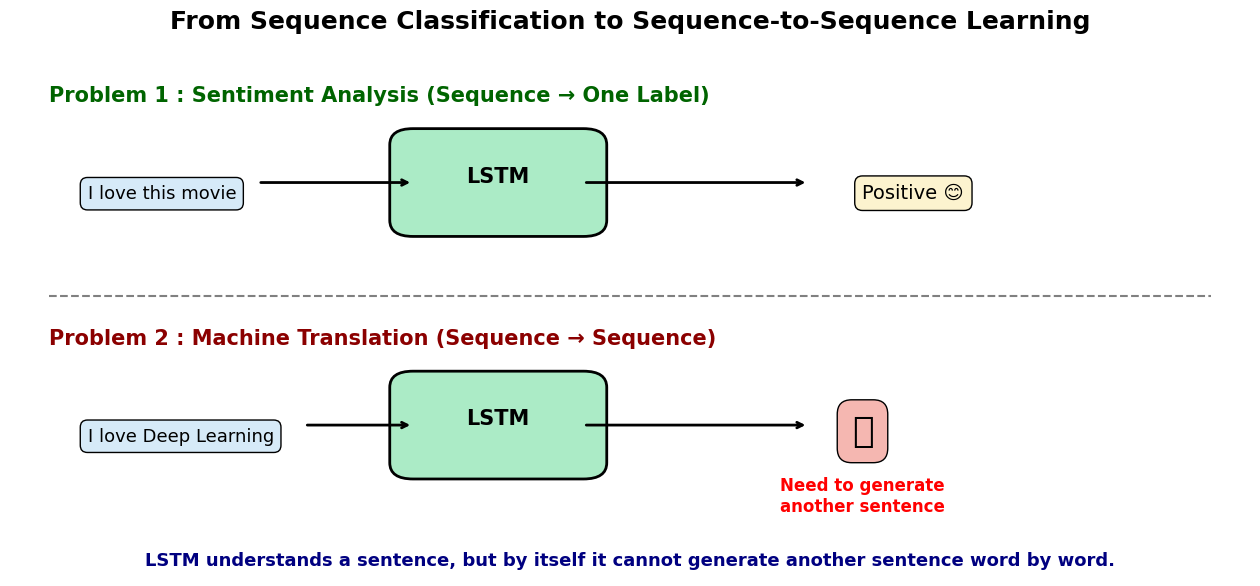

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16,7))

ax.set_xlim(0,16)
ax.set_ylim(0,10)
ax.axis("off")

# ======================================================
# TITLE
# ======================================================

plt.title(
    "From Sequence Classification to Sequence-to-Sequence Learning",
    fontsize=18,
    weight="bold"
)

# ======================================================
# FIRST EXAMPLE
# ======================================================

ax.text(
    0.5,
    8.8,
    "Problem 1 : Sentiment Analysis (Sequence → One Label)",
    fontsize=15,
    weight="bold",
    color="darkgreen"
)

# Input

ax.text(
    1,
    7,
    "I love this movie",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.4",
              facecolor="#D6EAF8",
              edgecolor="black")
)

# Arrow

ax.annotate(
    "",
    xy=(5.2,7.3),
    xytext=(3.2,7.3),
    arrowprops=dict(arrowstyle="->",lw=2)
)

# LSTM

lstm = FancyBboxPatch(
    (5.2,6.6),
    2.2,
    1.4,
    boxstyle="round,pad=0.3",
    facecolor="#ABEBC6",
    edgecolor="black",
    linewidth=2
)

ax.add_patch(lstm)

ax.text(
    6.3,
    7.3,
    "LSTM",
    fontsize=15,
    ha="center",
    weight="bold"
)

# Arrow

ax.annotate(
    "",
    xy=(10.3,7.3),
    xytext=(7.4,7.3),
    arrowprops=dict(arrowstyle="->",lw=2)
)

# Output

ax.text(
    11,
    7,
    "Positive 😊",
    fontsize=14,
    bbox=dict(boxstyle="round,pad=0.4",
              facecolor="#FCF3CF",
              edgecolor="black")
)

# ======================================================
# Divider
# ======================================================

ax.plot([0.5,15.5],[5.2,5.2],
        linestyle="--",
        color="gray")

# ======================================================
# SECOND EXAMPLE
# ======================================================

ax.text(
    0.5,
    4.3,
    "Problem 2 : Machine Translation (Sequence → Sequence)",
    fontsize=15,
    weight="bold",
    color="darkred"
)

# Input

ax.text(
    1,
    2.5,
    "I love Deep Learning",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.4",
              facecolor="#D6EAF8",
              edgecolor="black")
)

# Arrow

ax.annotate(
    "",
    xy=(5.2,2.8),
    xytext=(3.8,2.8),
    arrowprops=dict(arrowstyle="->",lw=2)
)

# LSTM

lstm2 = FancyBboxPatch(
    (5.2,2.1),
    2.2,
    1.4,
    boxstyle="round,pad=0.3",
    facecolor="#ABEBC6",
    edgecolor="black",
    linewidth=2
)

ax.add_patch(lstm2)

ax.text(
    6.3,
    2.8,
    "LSTM",
    fontsize=15,
    ha="center",
    weight="bold"
)

# Arrow

ax.annotate(
    "",
    xy=(10.3,2.8),
    xytext=(7.4,2.8),
    arrowprops=dict(arrowstyle="->",lw=2)
)

# Output

ax.text(
    11,
    2.5,
    "❓",
    fontsize=26,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.4",
              facecolor="#F5B7B1",
              edgecolor="black")
)

ax.text(
    11,
    1.2,
    "Need to generate\nanother sentence",
    fontsize=12,
    color="red",
    ha="center",
    weight="bold"
)

# ======================================================
# Bottom Note
# ======================================================

ax.text(
    8,
    0.2,
    "LSTM understands a sentence, but by itself it cannot generate another sentence word by word.",
    fontsize=13,
    ha="center",
    color="navy",
    weight="bold"
)

plt.show()

# 🧑‍💻 Implementing the Encoder in PyTorch

Now let's implement the Encoder.

Our Encoder consists of **two main layers**:

### 1️⃣ Embedding Layer

```python
nn.Embedding(...)
```

The Embedding layer converts **word IDs** into **dense numerical vectors**.

Example:

```text
Word IDs

[2, 7, 5]

↓

Embedding Layer

↓

[
 [0.42, 0.81, 0.19],
 [0.66, 0.27, 0.74],
 [0.13, 0.55, 0.91]
]
```

These vectors are much more meaningful than raw word IDs and can be processed by neural networks.

---

### 2️⃣ LSTM Layer

```python
nn.LSTM(...)
```

The LSTM reads the embedding vectors **one by one**.

For every input word, it updates its internal memory.

After reading the complete sentence, it returns:

- **outputs** → Hidden representation for every word.
- **hidden** → Final hidden state representing the entire sentence.
- **cell** → Final cell state used by the LSTM.

For a basic Encoder-Decoder architecture, we only pass the **Hidden State** and **Cell State** to the Decoder.

---

### Flow Inside the Encoder

```text
Sentence
      │
      ▼
Word IDs
      │
      ▼
Embedding Layer
      │
      ▼
Word Embeddings
      │
      ▼
LSTM
      │
      ▼
Hidden State
Cell State
```

---

##  What Does the Encoder Do?

The Encoder:

- Reads the input sentence **one word at a time**.
- Converts each word into an **embedding vector**.
- Processes these embeddings using an **LSTM**.
- Learns the meaning and context of the entire sentence.
- Produces a **Final Hidden State** and **Cell State**.

These two states summarize the information contained in the input sentence and are passed to the **Decoder**.

---

Let's implement this Encoder step by step.

In [ ]:
# ==========================================================
# ENCODER
# Understanding How the Encoder Works
# ==========================================================

import torch
import torch.nn as nn

# ==========================================================
# Encoder Definition
# ==========================================================

class Encoder(nn.Module):

    def __init__(self,
                 input_size,
                 embedding_size,
                 hidden_size):

        super().__init__()

        # Embedding Layer
        self.embedding = nn.Embedding(
            num_embeddings=input_size,
            embedding_dim=embedding_size
        )

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=hidden_size,
            batch_first=True
        )

    def forward(self, x):

        # Step 1
        embedded = self.embedding(x)

        # Step 2
        outputs, (hidden, cell) = self.lstm(embedded)

        return embedded, outputs, hidden, cell


# ==========================================================
# Example Input Sentence
# ==========================================================

sentence = "i love deep learning"

print("="*70)
print("INPUT SENTENCE")
print("="*70)
print(sentence)

# ==========================================================
# Tokenization
# ==========================================================

tokens = sentence.lower().split()

print("\n" + "="*70)
print("TOKENS")
print("="*70)
print(tokens)

# ==========================================================
# Vocabulary
# ==========================================================

vocab = {}

for word in tokens:

    if word not in vocab:

        vocab[word] = len(vocab)

print("\n" + "="*70)
print("VOCABULARY")
print("="*70)

for word, idx in vocab.items():

    print(f"{word:12} ---> {idx}")

# ==========================================================
# Convert Words to IDs
# ==========================================================

ids = [vocab[word] for word in tokens]

print("\n" + "="*70)
print("WORD IDS")
print("="*70)

print(ids)

# ==========================================================
# Convert into Tensor
# ==========================================================

source = torch.tensor([ids])

print("\n" + "="*70)
print("SOURCE TENSOR")
print("="*70)

print(source)

print("\nTensor Shape :", source.shape)

# ==========================================================
# Create Encoder
# ==========================================================

encoder = Encoder(

    input_size=len(vocab),

    embedding_size=8,

    hidden_size=16

)

# ==========================================================
# Forward Pass
# ==========================================================

embedded, outputs, hidden, cell = encoder(source)

# ==========================================================
# Embedding
# ==========================================================

print("\n" + "="*70)
print("EMBEDDING LAYER")
print("="*70)

print("Embedding Shape :", embedded.shape)

print("\nEmbedding Vector for Every Word\n")

for i, word in enumerate(tokens):

    print(f"{word}")

    print(embedded[0, i].detach().numpy())

    print()

# ==========================================================
# LSTM Outputs
# ==========================================================

print("\n" + "="*70)
print("LSTM OUTPUT AFTER EVERY WORD")
print("="*70)

print("Output Shape :", outputs.shape)

for i, word in enumerate(tokens):

    print(f"\nAfter Reading '{word}'")

    print(outputs[0, i].detach().numpy())

# ==========================================================
# Final Hidden State
# ==========================================================

print("\n" + "="*70)
print("FINAL HIDDEN STATE")
print("="*70)

print(hidden)

print("\nShape :", hidden.shape)

# ==========================================================
# Final Cell State
# ==========================================================

print("\n" + "="*70)
print("FINAL CELL STATE")
print("="*70)

print(cell)

print("\nShape :", cell.shape)

INPUT SENTENCE
i love deep learning

TOKENS
['i', 'love', 'deep', 'learning']

VOCABULARY
i            ---> 0
love         ---> 1
deep         ---> 2
learning     ---> 3

WORD IDS
[0, 1, 2, 3]

SOURCE TENSOR
tensor([[0, 1, 2, 3]])

Tensor Shape : torch.Size([1, 4])

EMBEDDING LAYER
Embedding Shape : torch.Size([1, 4, 8])

Embedding Vector for Every Word

i
[ 1.6146361   0.3289172  -0.98457265  0.41998753  1.2788175  -2.6241038
 -0.8067422  -0.7954511 ]

love
[-1.6244147   0.20220084  1.1095772  -0.94398206  0.7876289  -0.97622335
 -0.61899894 -1.3573422 ]

deep
[ 0.6058772   0.11524592  0.19014908  3.1622703   0.42643583 -1.9416598
 -0.28341272 -0.24157166]

learning
[-0.8800575   0.34705642 -0.27442715 -0.5410539  -0.56935537  0.7141071
  1.6634401  -0.81353956]


LSTM OUTPUT AFTER EVERY WORD
Output Shape : torch.Size([1, 4, 16])

After Reading 'i'
[ 0.20819     0.1767399   0.01908751  0.08795429  0.17187314  0.08648316
  0.1643092  -0.26555952 -0.09759115 -0.02094208  0.08340579  0.0

# The Decoder

The Encoder has already **understood** the input sentence.

It has converted the entire sentence into two tensors:

- **Hidden State**
- **Cell State**

However, these tensors are **not the final output**.

Our goal is to generate another sequence (for example, a translated sentence).

This is the responsibility of the **Decoder**.

---

## What Does the Decoder Do?

The Decoder:

- Receives the **Hidden State** and **Cell State** from the Encoder.
- Starts with a special token called **`<SOS>` (Start of Sequence)**.
- Predicts the **first output word**.
- Uses that word to predict the **next word**.
- Continues this process until it predicts **`<EOS>` (End of Sequence)**.

---

### Decoder Pipeline

```text
Hidden State + Cell State
            │
            ▼
        Decoder
            │
            ▼
        First Word
            │
            ▼
       Second Word
            │
            ▼
        Third Word
            │
            ▼
            ...
            │
            ▼
         <EOS>
```

Unlike the Encoder, which **reads** a sequence, the Decoder **generates** a sequence one word at a time.

In [ ]:
# ==========================================================
# DECODER
# Connected with the Encoder
# ==========================================================

import torch
import torch.nn as nn

# ==========================================================
# Decoder Definition
# ==========================================================

class Decoder(nn.Module):

    def __init__(self,
                 output_size,
                 embedding_size,
                 hidden_size):

        super().__init__()

        # Embedding Layer
        self.embedding = nn.Embedding(
            output_size,
            embedding_size
        )

        # LSTM Layer
        self.lstm = nn.LSTM(
            embedding_size,
            hidden_size,
            batch_first=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self,
                x,
                hidden,
                cell):

        # (batch,) -> (batch,1)

        x = x.unsqueeze(1)

        # Embedding

        embedded = self.embedding(x)

        # LSTM

        output, (hidden, cell) = self.lstm(
            embedded,
            (hidden, cell)
        )

        # Prediction

        prediction = self.fc(
            output.squeeze(1)
        )

        return prediction, hidden, cell


# ==========================================================
# Target Vocabulary
# ==========================================================

target_vocab = {

    "<SOS>" : 0,

    "j'aime" : 1,

    "deep" : 2,

    "learning" : 3,

    "<EOS>" : 4

}

id_to_word = {
    v:k for k,v in target_vocab.items()
}

# ==========================================================
# Create Decoder
# ==========================================================

decoder = Decoder(

    output_size=len(target_vocab),

    embedding_size=8,

    hidden_size=16

)

# ==========================================================
# Start Token
# ==========================================================

start_token = torch.tensor([target_vocab["<SOS>"]])

print("="*70)
print("DECODER INPUT")
print("="*70)

print("Start Token : <SOS>")

print("\nUsing Hidden State from Encoder")

print("Hidden Shape :", hidden.shape)

print("Cell Shape   :", cell.shape)

# ==========================================================
# Decoder Forward Pass
# ==========================================================

prediction, hidden, cell = decoder(
    start_token,
    hidden,
    cell
)

# ==========================================================
# Results
# ==========================================================

print("\n" + "="*70)
print("DECODER OUTPUT")
print("="*70)

print("Prediction Shape :", prediction.shape)

print("\nVocabulary Scores")

print(prediction)

predicted_id = torch.argmax(
    prediction,
    dim=1
).item()

print("\nPredicted Token ID :", predicted_id)

print("Predicted Word :", id_to_word[predicted_id])

print("\nUpdated Hidden Shape :", hidden.shape)

print("Updated Cell Shape :", cell.shape)



DECODER INPUT
Start Token : <SOS>

Using Hidden State from Encoder
Hidden Shape : torch.Size([1, 1, 16])
Cell Shape   : torch.Size([1, 1, 16])

DECODER OUTPUT
Prediction Shape : torch.Size([1, 5])

Vocabulary Scores
tensor([[-0.0846,  0.0111,  0.0665,  0.1242,  0.3475]],
       grad_fn=<AddmmBackward0>)

Predicted Token ID : 4
Predicted Word : <EOS>

Updated Hidden Shape : torch.Size([1, 1, 16])
Updated Cell Shape : torch.Size([1, 1, 16])


#  Building the Complete Sequence-to-Sequence (Seq2Seq) Model

So far, we have implemented the **Encoder** and the **Decoder** separately.

Now it is time to combine both into a single architecture called the **Sequence-to-Sequence (Seq2Seq) Model**.

---

##  How Does the Seq2Seq Model Work?

The complete workflow is:

1. The **Encoder** reads the entire input sentence.
2. It generates the **Hidden State** and **Cell State**.
3. These states are passed to the **Decoder**.
4. The Decoder starts with the **`<SOS>` (Start of Sequence)** token.
5. It predicts the first output word.
6. The predicted (or actual during training) word is used to predict the next word.
7. This process continues until the complete output sentence is generated.

---

### Complete Seq2Seq Pipeline

```text
Input Sentence
        │
        ▼
     Encoder
        │
        ▼
Hidden State
Cell State
        │
        ▼
     Decoder
        │
        ▼
Word 1
        │
        ▼
Word 2
        │
        ▼
Word 3
        │
        ▼
...
        │
        ▼
<EOS>
```

---

## Teacher Forcing

During training, instead of feeding the **predicted word** back into the Decoder, we feed the **actual target word**.

This technique is called **Teacher Forcing**.

Teacher Forcing helps the model learn faster and improves training stability.

In this implementation, Teacher Forcing is applied using:

```python
x = target[:, t]
```

Instead of using the predicted word, the Decoder receives the correct word from the target sentence.

In [ ]:
# ==========================================================
# COMPLETE SEQUENCE TO SEQUENCE MODEL
# ==========================================================

import torch
import torch.nn as nn

# ==========================================================
# Seq2Seq Model
# ==========================================================

class Seq2Seq(nn.Module):

    def __init__(self,
                 encoder,
                 decoder):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self,
                source,
                target):

        batch_size = source.shape[0]

        target_len = target.shape[1]

        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(
            batch_size,
            target_len,
            vocab_size
        )

        # ---------------------------------------------
        # Encoder
        # ---------------------------------------------

        _, _, hidden, cell = self.encoder(source)

        # ---------------------------------------------
        # First Decoder Input (<SOS>)
        # ---------------------------------------------

        x = target[:,0]

        # ---------------------------------------------
        # Decode One Word at a Time
        # ---------------------------------------------

        for t in range(1,target_len):

            prediction, hidden, cell = self.decoder(
                x,
                hidden,
                cell
            )

            outputs[:,t] = prediction

            # Teacher Forcing

            x = target[:,t]

        return outputs


# ==========================================================
# Example
# ==========================================================

source = torch.tensor([[0,1,2,3]])

target = torch.tensor([[0,1,2,3,4]])

model = Seq2Seq(
    encoder,
    decoder
)

outputs = model(
    source,
    target
)

# ==========================================================
# Results
# ==========================================================

print("="*70)
print("SEQ2SEQ OUTPUT")
print("="*70)

print(outputs)

print("\nOutput Shape :", outputs.shape)

print("\nBatch Size :", outputs.shape[0])

print("Target Length :", outputs.shape[1])

print("Vocabulary Size :", outputs.shape[2])

# ==========================================================
# Convert Predictions into Words
# ==========================================================

predicted_ids = torch.argmax(
    outputs,
    dim=2
)

print("\n" + "="*70)
print("PREDICTED TOKEN IDS")
print("="*70)

print(predicted_ids)

print("\nPredicted Words")

for token in predicted_ids[0]:

    print(id_to_word[token.item()], end=" ")

print()



SEQ2SEQ OUTPUT
tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [-0.0846,  0.0111,  0.0665,  0.1242,  0.3475],
         [-0.1378,  0.1477, -0.0034,  0.1480,  0.2611],
         [-0.1674,  0.1219,  0.0185,  0.1528,  0.2222],
         [-0.1941,  0.0271,  0.0573,  0.1301,  0.2235]]], grad_fn=<CopySlices>)

Output Shape : torch.Size([1, 5, 5])

Batch Size : 1
Target Length : 5
Vocabulary Size : 5

PREDICTED TOKEN IDS
tensor([[0, 4, 4, 4, 4]])

Predicted Words
<SOS> <EOS> <EOS> <EOS> <EOS> 


EXAMPLE

In [ ]:
# ==========================================================
# BLOCK 1
# Toy English → French Dataset
# Preprocessing + Vocabulary + DataLoader
# ==========================================================

import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# ==========================================================
# Toy Dataset
# ==========================================================

pairs = [

    ("i am a student",          "je suis un etudiant"),
    ("i love ai",               "j aime ia"),
    ("how are you",             "comment allez vous"),
    ("good morning",            "bonjour"),
    ("good night",              "bonne nuit"),
    ("thank you",               "merci"),
    ("you are welcome",         "de rien"),
    ("i love deep learning",    "j aime apprentissage profond"),
    ("he is a teacher",         "il est un enseignant"),
    ("she is a doctor",         "elle est un medecin"),
    ("this is my book",         "c est mon livre"),
    ("where is the school",     "ou est l ecole"),
    ("i like coffee",           "j aime cafe"),
    ("see you tomorrow",        "a demain"),
    ("what is your name",       "quel est votre nom"),
]

# ==========================================================
# Special Tokens
# ==========================================================

PAD = "<PAD>"
SOS = "<SOS>"
EOS = "<EOS>"
UNK = "<UNK>"

MAX_LEN = 10

# ==========================================================
# Tokenization
# ==========================================================

english = []
french = []

for en,fr in pairs:

    english.append(en.lower().split())

    french.append([SOS] + fr.lower().split() + [EOS])

print("="*60)
print("Sample Pair")
print("="*60)

print("English :",english[0])
print("French  :",french[0])

# ==========================================================
# Build Vocabulary
# ==========================================================

def build_vocab(sentences):

    counter = Counter()

    for sent in sentences:

        counter.update(sent)

    vocab = {

        PAD:0,

        SOS:1,

        EOS:2,

        UNK:3

    }

    for word in counter:

        if word not in vocab:

            vocab[word]=len(vocab)

    return vocab

source_vocab = build_vocab(english)

target_vocab = build_vocab(french)

print("\nEnglish Vocabulary :",len(source_vocab))
print("French Vocabulary  :",len(target_vocab))

# Reverse Vocabulary

idx2target = {

    idx:word

    for word,idx in target_vocab.items()

}

# ==========================================================
# Encoding
# ==========================================================

def encode(sentence,vocab):

    return [

        vocab.get(word,vocab[UNK])

        for word in sentence

    ]

source = [

    encode(x,source_vocab)

    for x in english

]

target = [

    encode(x,target_vocab)

    for x in french

]

# ==========================================================
# Padding
# ==========================================================

def pad(sequence):

    if len(sequence)>=MAX_LEN:

        return sequence[:MAX_LEN]

    return sequence+[0]*(MAX_LEN-len(sequence))

source = [

    pad(x)

    for x in source

]

target = [

    pad(x)

    for x in target

]

# ==========================================================
# Dataset
# ==========================================================

class TranslationDataset(Dataset):

    def __init__(self,source,target):

        self.source=source

        self.target=target

    def __len__(self):

        return len(self.source)

    def __getitem__(self,index):

        return (

            torch.tensor(self.source[index]),

            torch.tensor(self.target[index])

        )

dataset = TranslationDataset(

    source,

    target

)

loader = DataLoader(

    dataset,

    batch_size=2,

    shuffle=True

)

# ==========================================================
# Display
# ==========================================================

print("\n"+"="*60)
print("Dataset Ready")
print("="*60)

print("Total Samples :",len(dataset))

print("Total Batches :",len(loader))

sample_source,sample_target=next(iter(loader))

print("\nSource Shape :",sample_source.shape)

print("Target Shape :",sample_target.shape)

print("\nExample Source IDs")

print(sample_source[0])

print("\nExample Target IDs")

print(sample_target[0])

print("\nTarget Vocabulary")

print(idx2target)

Sample Pair
English : ['i', 'am', 'a', 'student']
French  : ['<SOS>', 'je', 'suis', 'un', 'etudiant', '<EOS>']

English Vocabulary : 38
French Vocabulary  : 39

Dataset Ready
Total Samples : 15
Total Batches : 8

Source Shape : torch.Size([2, 10])
Target Shape : torch.Size([2, 10])

Example Source IDs
tensor([35, 21, 36, 37,  0,  0,  0,  0,  0,  0])

Example Target IDs
tensor([ 1, 36, 23, 37, 38,  2,  0,  0,  0,  0])

Target Vocabulary
{0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>', 4: 'je', 5: 'suis', 6: 'un', 7: 'etudiant', 8: 'j', 9: 'aime', 10: 'ia', 11: 'comment', 12: 'allez', 13: 'vous', 14: 'bonjour', 15: 'bonne', 16: 'nuit', 17: 'merci', 18: 'de', 19: 'rien', 20: 'apprentissage', 21: 'profond', 22: 'il', 23: 'est', 24: 'enseignant', 25: 'elle', 26: 'medecin', 27: 'c', 28: 'mon', 29: 'livre', 30: 'ou', 31: 'l', 32: 'ecole', 33: 'cafe', 34: 'a', 35: 'demain', 36: 'quel', 37: 'votre', 38: 'nom'}


In [ ]:
# ==========================================================
# BLOCK 2
# Encoder + Decoder + Seq2Seq
# ==========================================================

import torch
import torch.nn as nn

# ==========================================================
# Hyperparameters
# ==========================================================

EMBEDDING_SIZE = 64
HIDDEN_SIZE = 128

# ==========================================================
# Encoder
# ==========================================================

class Encoder(nn.Module):

    def __init__(self,
                 input_size,
                 embedding_size,
                 hidden_size):

        super().__init__()

        self.embedding = nn.Embedding(
            input_size,
            embedding_size
        )

        self.lstm = nn.LSTM(
            embedding_size,
            hidden_size,
            batch_first=True
        )

    def forward(self,x):

        embedded = self.embedding(x)

        outputs,(hidden,cell)=self.lstm(embedded)

        return hidden,cell


# ==========================================================
# Decoder
# ==========================================================

class Decoder(nn.Module):

    def __init__(self,
                 output_size,
                 embedding_size,
                 hidden_size):

        super().__init__()

        self.embedding = nn.Embedding(
            output_size,
            embedding_size
        )

        self.lstm = nn.LSTM(
            embedding_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self,
                x,
                hidden,
                cell):

        # (batch,) -> (batch,1)

        x = x.unsqueeze(1)

        embedded = self.embedding(x)

        output,(hidden,cell)=self.lstm(
            embedded,
            (hidden,cell)
        )

        prediction = self.fc(
            output.squeeze(1)
        )

        return prediction,hidden,cell


# ==========================================================
# Seq2Seq
# ==========================================================

class Seq2Seq(nn.Module):

    def __init__(self,
                 encoder,
                 decoder):

        super().__init__()

        self.encoder = encoder

        self.decoder = decoder


    def forward(self,
                source,
                target):

        batch_size = source.shape[0]

        target_len = target.shape[1]

        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(
            batch_size,
            target_len,
            vocab_size
        ).to(source.device)

        # ---------------- Encoder ----------------

        hidden,cell = self.encoder(source)

        # First decoder input = <SOS>

        x = target[:,0]

        # ---------------- Decoder ----------------

        for t in range(1,target_len):

            prediction,hidden,cell = self.decoder(
                x,
                hidden,
                cell
            )

            outputs[:,t] = prediction

            # Teacher Forcing

            x = target[:,t]

        return outputs


# ==========================================================
# Create Model
# ==========================================================

encoder = Encoder(

    input_size=len(source_vocab),

    embedding_size=EMBEDDING_SIZE,

    hidden_size=HIDDEN_SIZE

)

decoder = Decoder(

    output_size=len(target_vocab),

    embedding_size=EMBEDDING_SIZE,

    hidden_size=HIDDEN_SIZE

)

model = Seq2Seq(
    encoder,
    decoder
)

# ==========================================================
# Test Forward Pass
# ==========================================================

sample_source,sample_target = next(iter(loader))

outputs = model(
    sample_source,
    sample_target
)

print("="*60)
print("Seq2Seq Model Created Successfully")
print("="*60)

print()

print("Source Shape :",sample_source.shape)

print("Target Shape :",sample_target.shape)

print("Output Shape :",outputs.shape)

print()

print("Output Meaning")

print()

print("Batch Size      :",outputs.shape[0])

print("Target Length   :",outputs.shape[1])

print("Vocabulary Size :",outputs.shape[2])

Seq2Seq Model Created Successfully

Source Shape : torch.Size([2, 10])
Target Shape : torch.Size([2, 10])
Output Shape : torch.Size([2, 10, 39])

Output Meaning

Batch Size      : 2
Target Length   : 10
Vocabulary Size : 39


In [ ]:
# ==========================================================
# BLOCK 3
# Training the Seq2Seq Model
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

# ----------------------------------------------------------
# Loss Function
# ----------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    ignore_index=0      # Ignore PAD token
)

# ----------------------------------------------------------
# Optimizer
# ----------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ----------------------------------------------------------
# Training Settings
# ----------------------------------------------------------

EPOCHS = 200

print("="*60)
print("Training Started...")
print("="*60)

# ----------------------------------------------------------
# Training Loop
# ----------------------------------------------------------

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for source, target in loader:

        source = source.to(device)

        target = target.to(device)

        optimizer.zero_grad()

        # -----------------------------
        # Forward Pass
        # -----------------------------

        output = model(source, target)

        # output
        # [batch , target_len , vocab]

        output = output[:,1:,:].reshape(-1, output.shape[2])

        target = target[:,1:].reshape(-1)

        loss = criterion(
            output,
            target
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    if (epoch+1)%20==0:

        print(
            f"Epoch {epoch+1:3d} | Loss = {total_loss:.4f}"
        )

print("\n"+"="*60)
print("Training Completed!")
print("="*60)

# ----------------------------------------------------------
# Save Model
# ----------------------------------------------------------

torch.save(
    model.state_dict(),
    "seq2seq_translation.pth"
)

print("\nModel Saved Successfully.")

Training Started...
Epoch  20 | Loss = 8.1682
Epoch  40 | Loss = 6.1357
Epoch  60 | Loss = 5.0005
Epoch  80 | Loss = 2.3322
Epoch 100 | Loss = 0.6934
Epoch 120 | Loss = 0.2470
Epoch 140 | Loss = 0.1422
Epoch 160 | Loss = 0.0924
Epoch 180 | Loss = 0.0672
Epoch 200 | Loss = 0.0528

Training Completed!

Model Saved Successfully.


In [ ]:
# ==========================================================
# BLOCK 4
# English -> French Translation
# ==========================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()

# ----------------------------------------------------------
# Reverse Vocabulary
# ----------------------------------------------------------

idx2target = {

    idx: word

    for word, idx in target_vocab.items()

}

# ----------------------------------------------------------
# Translation Function
# ----------------------------------------------------------

def translate(sentence):

    # -----------------------------
    # Tokenize
    # -----------------------------

    tokens = sentence.lower().split()

    # -----------------------------
    # Convert to IDs
    # -----------------------------

    source = []

    for word in tokens:

        source.append(

            source_vocab.get(
                word,
                source_vocab[UNK]
            )

        )

    # -----------------------------
    # Padding
    # -----------------------------

    if len(source) < MAX_LEN:

        source += [0]*(MAX_LEN-len(source))

    else:

        source = source[:MAX_LEN]

    source = torch.tensor([source]).to(device)

    # -----------------------------
    # Encoder
    # -----------------------------

    with torch.no_grad():

        hidden, cell = model.encoder(source)

    # -----------------------------
    # Decoder Starts with <SOS>
    # -----------------------------

    x = torch.tensor(
        [target_vocab[SOS]]
    ).to(device)

    translated = []

    # -----------------------------
    # Predict One Word at a Time
    # -----------------------------

    for _ in range(MAX_LEN):

        with torch.no_grad():

            prediction, hidden, cell = model.decoder(
                x,
                hidden,
                cell
            )

        best_word = prediction.argmax(1).item()

        word = idx2target[best_word]

        # Stop if <EOS>

        if word == EOS:

            break

        translated.append(word)

        # Prediction becomes next input

        x = torch.tensor(
            [best_word]
        ).to(device)

    return " ".join(translated)


# ==========================================================
# Demo
# ==========================================================

print("="*60)
print("English → French Translator")
print("="*60)

while True:

    sentence = input("\nEnter English Sentence : ")

    if sentence.lower() == "exit":

        break

    french = translate(sentence)

    print("\nFrench Translation :")

    print(french)

English → French Translator

Enter English Sentence : hello everyone

French Translation :
bonne nuit

Enter English Sentence : good night

French Translation :
bonne nuit

Enter English Sentence : bye

French Translation :
bonne nuit

Enter English Sentence : i love AI

French Translation :
j aime ia

Enter English Sentence : I love science

French Translation :
j aime ia


KeyboardInterrupt: Interrupted by user

In [ ]:
# ==========================================================
# Machine Translation
# Encoder-Decoder Transformer
# English --> French
# Complete Gradio Application
# ==========================================================

import gradio as gr
from transformers import MarianMTModel, MarianTokenizer

# ==========================================================
# Load Pretrained Encoder-Decoder Model
# ==========================================================

MODEL_NAME = "Helsinki-NLP/opus-mt-en-fr"

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model = MarianMTModel.from_pretrained(MODEL_NAME)

# ==========================================================
# Translation Function
# ==========================================================

def translate_to_french(text):

    if text.strip() == "":
        return "Please enter some English text."

    # Encoder Input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    # Encoder + Decoder Translation
    translated = model.generate(**inputs)

    # Decode Output
    french = tokenizer.decode(
        translated[0],
        skip_special_tokens=True
    )

    return french

# ==========================================================
# Examples
# ==========================================================

examples = [
    ["Hello, how are you?"],
    ["I love artificial intelligence."],
    ["Machine learning is very interesting."],
    ["My name is John."],
    ["Pakistan is a beautiful country."],
    ["Good morning everyone."],
    ["I am learning deep learning."],
    ["Welcome to this machine translation demo."]
]

# ==========================================================
# Gradio UI
# ==========================================================

demo = gr.Interface(

    fn=translate_to_french,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Type English text here..."
    ),

    outputs=gr.Textbox(
        lines=5,
        label="French Translation"
    ),

    title="English → French Machine Translation",

    description="""
This application demonstrates a **pre-trained Encoder-Decoder Transformer**
for Machine Translation.

Architecture:

English Sentence
      ↓
Tokenizer
      ↓
Encoder
      ↓
Context Vector
      ↓
Decoder
      ↓
French Sentence
""",

    examples=examples,

    theme="soft"
)

# ==========================================================
# Launch
# ==========================================================

demo.launch()

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a2446becc4338be12.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Limitation of the Basic Encoder–Decoder Architecture

We have successfully built a **Sequence-to-Sequence (Seq2Seq)** model using an **Encoder** and a **Decoder**.

The Encoder reads the entire input sentence and converts it into:

- Final Hidden State
- Final Cell State

These two tensors are then passed to the Decoder, which generates the output sentence one word at a time.

---

## The Problem

The Decoder receives **only one representation** of the entire input sentence:

```text
Hidden State
Cell State
```

This is called the **Context Vector**.

For short sentences, this works reasonably well.

Example:

```text
Input:
I love AI

↓

Context Vector

↓

Output:
J'aime l'IA
```

However, what happens when the input sentence becomes very long?

```text
Yesterday morning I went to the university where I met my professor who was teaching Deep Learning and Computer Vision...
```

Now the Encoder must compress **all the information** from this long sentence into **one fixed-size context vector**.

As the sentence length increases:

- Important information is forgotten.
- Earlier words become difficult to remember.
- Translation quality decreases.
- Long-distance relationships between words are lost.

This is known as the **Information Bottleneck Problem**.

---

## Why Does This Happen?

In the basic Seq2Seq architecture:

- The Encoder processes every input word.
- But the Decoder only receives the **final Hidden State** and **Cell State**.
- The intermediate hidden states produced after each input word are discarded.

```text
Encoder

Word 1 → h₁
Word 2 → h₂
Word 3 → h₃
Word 4 → h₄

                Only h₄
                  │
                  ▼
              Decoder
```

The Decoder has **no access** to:

- h₁
- h₂
- h₃

It only sees **h₄**, the final hidden state.

---

## Solution: Attention

Instead of relying on a single context vector, the Decoder should be able to **look back at all Encoder hidden states** whenever it needs information.

Rather than remembering everything in one vector, the Decoder learns **where to focus** while generating each output word.

This idea is called the **Attention Mechanism**.

With Attention, the Decoder receives:

- Final Hidden State
- Cell State
- All Encoder Hidden States

This allows the model to focus on the most relevant words in the input sentence during translation.

In the next section, we will extend our Encoder–Decoder model by introducing the **Attention Mechanism**, which significantly improves translation quality, especially for long sentences.

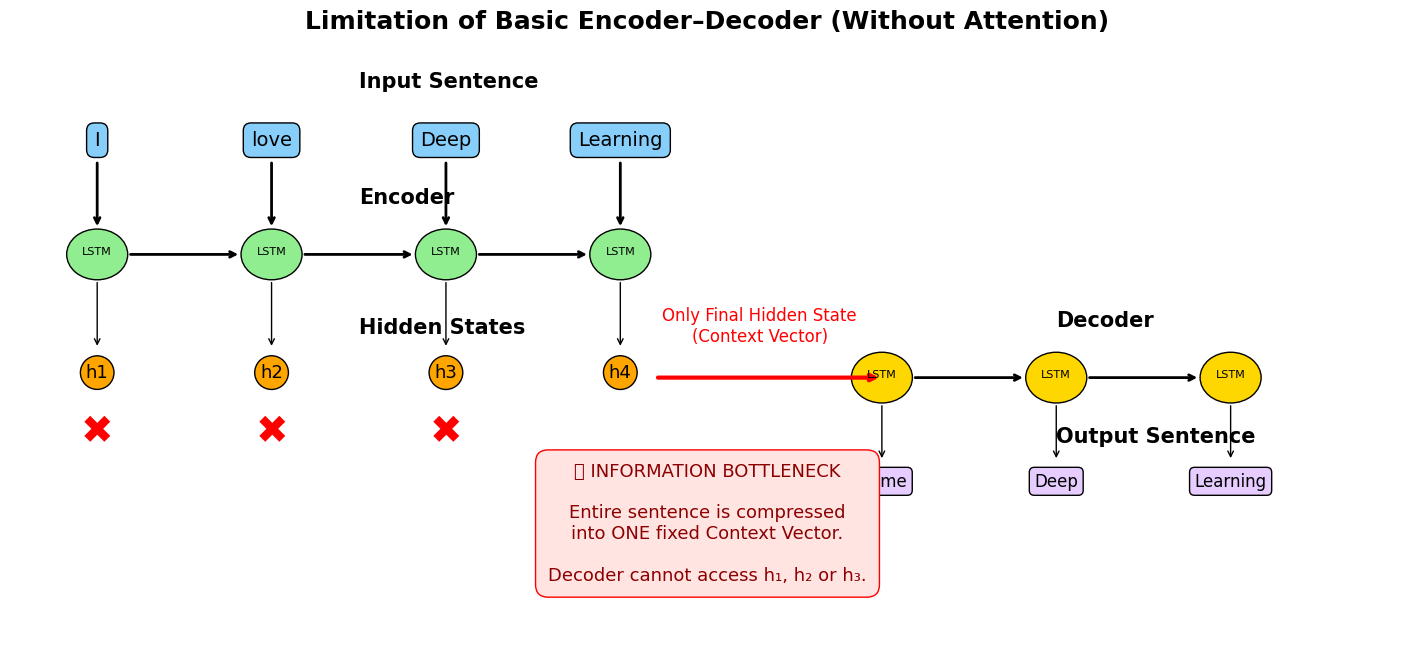

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18,8))

# ==========================================================
# INPUT SENTENCE
# ==========================================================

input_words = ["I", "love", "Deep", "Learning"]

x_input = [1, 3, 5, 7]

for x, word in zip(x_input, input_words):

    ax.text(
        x,
        7,
        word,
        fontsize=14,
        ha='center',
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="#87CEFA",
            edgecolor="black"
        )
    )

# ==========================================================
# ENCODER
# ==========================================================

encoder_x = [1,3,5,7]

for x in encoder_x:

    circle = plt.Circle(
        (x,5.5),
        0.35,
        color="#90EE90",
        ec="black"
    )

    ax.add_patch(circle)

    ax.text(
        x,
        5.5,
        "LSTM",
        fontsize=8,
        ha='center'
    )

# arrows

for x in encoder_x:

    ax.annotate(
        "",
        xy=(x,5.85),
        xytext=(x,6.8),
        arrowprops=dict(arrowstyle="->",lw=2)
    )

# connections

for i in range(len(encoder_x)-1):

    ax.annotate(
        "",
        xy=(encoder_x[i+1]-0.35,5.5),
        xytext=(encoder_x[i]+0.35,5.5),
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        )
    )

# ==========================================================
# HIDDEN STATES
# ==========================================================

hidden_y = 3.8

for i,x in enumerate(encoder_x):

    ax.text(
        x,
        hidden_y,
        f"h{i+1}",
        fontsize=13,
        ha='center',
        bbox=dict(
            boxstyle="circle",
            facecolor="orange",
            edgecolor="black"
        )
    )

    ax.annotate(
        "",
        xy=(x,4.2),
        xytext=(x,5.15),
        arrowprops=dict(arrowstyle="->")
    )

# ==========================================================
# RED CROSS ON LOST STATES
# ==========================================================

for x in encoder_x[:-1]:

    ax.text(
        x,
        2.9,
        "✖",
        fontsize=28,
        color="red",
        ha='center'
    )

# ==========================================================
# CONTEXT VECTOR
# ==========================================================

ax.annotate(
    "",
    xy=(10,3.8),
    xytext=(7.4,3.8),
    arrowprops=dict(
        arrowstyle="->",
        lw=3,
        color="red"
    )
)

ax.text(
    8.6,
    4.3,
    "Only Final Hidden State\n(Context Vector)",
    fontsize=12,
    color="red",
    ha="center"
)

# ==========================================================
# DECODER
# ==========================================================

decoder_x = [10,12,14]

decoder_words = ["J'aime","Deep","Learning"]

for i,x in enumerate(decoder_x):

    circle = plt.Circle(
        (x,3.8),
        0.35,
        color="gold",
        ec="black"
    )

    ax.add_patch(circle)

    ax.text(
        x,
        3.8,
        "LSTM",
        fontsize=8,
        ha="center"
    )

    ax.text(
        x,
        2.3,
        decoder_words[i],
        fontsize=12,
        ha="center",
        bbox=dict(
            boxstyle="round",
            facecolor="#E6CCFF",
            edgecolor="black"
        )
    )

    ax.annotate(
        "",
        xy=(x,2.65),
        xytext=(x,3.45),
        arrowprops=dict(arrowstyle="->")
    )

for i in range(len(decoder_x)-1):

    ax.annotate(
        "",
        xy=(decoder_x[i+1]-0.35,3.8),
        xytext=(decoder_x[i]+0.35,3.8),
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        )
    )

# ==========================================================
# BOTTLENECK BOX
# ==========================================================

ax.text(
    8,
    1,
    "❌ INFORMATION BOTTLENECK\n\n"
    "Entire sentence is compressed\n"
    "into ONE fixed Context Vector.\n\n"
    "Decoder cannot access h₁, h₂ or h₃.",
    fontsize=13,
    ha="center",
    color="darkred",
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="#FFE4E1",
        edgecolor="red"
    )
)

# ==========================================================

ax.text(4,7.8,"Input Sentence",fontsize=15,fontweight='bold')

ax.text(4,6.2,"Encoder",fontsize=15,fontweight='bold')

ax.text(4,4.4,"Hidden States",fontsize=15,fontweight='bold')

ax.text(12,4.5,"Decoder",fontsize=15,fontweight='bold')

ax.text(12,2.9,"Output Sentence",fontsize=15,fontweight='bold')

ax.set_xlim(0,16)

ax.set_ylim(0,8.5)

ax.axis("off")

plt.title(
    "Limitation of Basic Encoder–Decoder (Without Attention)",
    fontsize=18,
    weight="bold"
)

plt.show()

# Basic Attention Mechanism

In [ ]:
# ==========================================================
# Understanding the Basic Idea of Attention
# Simple Example
# ==========================================================

import numpy as np

# ==========================================================
# Input Sentence
# ==========================================================

sentence = [

    "The",
    "cat",
    "sat",
    "on",
    "the",
    "mat"

]

print("="*60)
print("Input Sentence")
print("="*60)

print(" ".join(sentence))

print("\nQuestion : Who sat on the mat?")

# ==========================================================
# Imagine the model assigns these importance scores
# (For demonstration only)
# ==========================================================

importance_scores = np.array([

    0.10,   # The

    0.90,   # cat

    0.30,   # sat

    0.05,   # on

    0.05,   # the

    0.10    # mat

])

print("\n"+"="*60)
print("Raw Importance Scores")
print("="*60)

for word,score in zip(sentence,importance_scores):

    print(f"{word:10} -> {score:.2f}")

# ==========================================================
# Softmax Function
# ==========================================================

def softmax(x):

    exp = np.exp(x - np.max(x))

    return exp / exp.sum()

# ==========================================================
# Attention Weights
# ==========================================================

attention = softmax(
    importance_scores
)

print("\n"+"="*60)
print("Attention Weights")
print("="*60)

print(f"{'Word':10} {'Score':>8} {'Attention':>12}")

print("-"*36)

for word,score,weight in zip(

        sentence,

        importance_scores,

        attention):

    print(

        f"{word:10}"

        f"{score:8.2f}"

        f"{weight:12.3f}"

    )

# ==========================================================
# Highest Attention
# ==========================================================

best = np.argmax(attention)

print("\n"+"="*60)
print("Highest Attention")
print("="*60)

print(

    f"The Decoder focuses MOST on "

    f"'{sentence[best]}'"

)

print(

    f"\nAttention Weight = "

    f"{attention[best]:.3f}"

)


Input Sentence
The cat sat on the mat

Question : Who sat on the mat?

Raw Importance Scores
The        -> 0.10
cat        -> 0.90
sat        -> 0.30
on         -> 0.05
the        -> 0.05
mat        -> 0.10

Attention Weights
Word          Score    Attention
------------------------------------
The           0.10       0.136
cat           0.90       0.303
sat           0.30       0.166
on            0.05       0.129
the           0.05       0.129
mat           0.10       0.136

Highest Attention
The Decoder focuses MOST on 'cat'

Attention Weight = 0.303

Conclusion


Without Attention

↓

Every word is treated almost equally.

--------------------------------------------

With Attention

↓

The model learns

which words are more important

for the current prediction.

--------------------------------------------

In this example,

the Decoder gives the highest importance

to the word

'cat'

because it is most relevant

to answering the question.

This importance is called

Attention 

Calculation

In [ ]:
# ==========================================================
# Understanding Attention Scores
# Step-by-Step
# ==========================================================

import numpy as np

# ==========================================================
# Encoder Hidden States
# ==========================================================

print("="*60)
print("Encoder Hidden States")
print("="*60)

words = ["I", "Love", "Deep", "Learning"]

encoder_states = np.array([

    [2,1],

    [1,3],

    [4,5],

    [1,0]

])

for word,state in zip(words,encoder_states):

    print(f"{word:10} -> {state}")

# ==========================================================
# Decoder Hidden State
# ==========================================================

decoder_state = np.array([3,4])

print("\n"+"="*60)
print("Current Decoder Hidden State")
print("="*60)

print(decoder_state)

# ==========================================================
# Dot Product Similarity
# ==========================================================

print("\n"+"="*60)
print("Step 1 : Similarity Scores")
print("="*60)

scores=[]

for word,state in zip(words,encoder_states):

    score=np.dot(

        decoder_state,

        state

    )

    scores.append(score)

    print(

        f"{word:10} "

        f"Dot Product = "

        f"{score}"

    )

scores=np.array(scores)

# ==========================================================
# Softmax
# ==========================================================

print("\n"+"="*60)
print("Step 2 : Softmax")
print("="*60)

exp=np.exp(

    scores-

    np.max(scores)

)

attention=exp/exp.sum()

print(f"{'Word':10}{'Score':>10}{'Attention':>15}")

print("-"*38)

for word,score,weight in zip(

        words,

        scores,

        attention):

    print(

        f"{word:10}"

        f"{score:10.2f}"

        f"{weight:15.3f}"

    )

# ==========================================================
# Highest Attention
# ==========================================================

best=np.argmax(attention)

print("\n"+"="*60)
print("Highest Attention")
print("="*60)

print(

    f"Decoder focuses mostly on "

    f"'{words[best]}'"

)

# ==========================================================
# Context Vector
# ==========================================================

print("\n"+"="*60)
print("Step 3 : Context Vector")
print("="*60)

context=np.sum(

    attention.reshape(-1,1)

    *

    encoder_states,

    axis=0

)

print(context)


Encoder Hidden States
I          -> [2 1]
Love       -> [1 3]
Deep       -> [4 5]
Learning   -> [1 0]

Current Decoder Hidden State
[3 4]

Step 1 : Similarity Scores
I          Dot Product = 10
Love       Dot Product = 15
Deep       Dot Product = 32
Learning   Dot Product = 3

Step 2 : Softmax
Word           Score      Attention
--------------------------------------
I              10.00          0.000
Love           15.00          0.000
Deep           32.00          1.000
Learning        3.00          0.000

Highest Attention
Decoder focuses mostly on 'Deep'

Step 3 : Context Vector
[3.99999988 4.99999992]

Explanation


Step 1

Decoder compared itself

with every Encoder hidden state.

↓

Step 2

Dot Product measured similarity.

↓

Step 3

Softmax converted

Similarity Scores

↓

Attention Weights

↓

Step 4

Weighted Average

↓

Context Vector

This Context Vector

contains information from

ALL Encoder hidden states,

instead of using

only the Final Hidden State.




# **Self-Attention Mechanism**

**Understanding Self Attention Create Input Embeddings**

In [ ]:
import torch

# ----------------------------------------------------------
# Suppose our sentence has 3 words.
# Each word is represented by a 4-dimensional embedding.
# ----------------------------------------------------------

x = [
    [1, 0, 1, 0],   # Word 1
    [0, 2, 0, 2],   # Word 2
    [1, 1, 1, 1]    # Word 3
]

x = torch.tensor(x, dtype=torch.float32)

print("Input Embeddings")
print(x)

print("\nShape :", x.shape)

Input Embeddings
tensor([[1., 0., 1., 0.],
        [0., 2., 0., 2.],
        [1., 1., 1., 1.]])

Shape : torch.Size([3, 4])



*Why Self Attention Needs Query, Key and Value*


Every word is converted into THREE different vectors.



*   Query  -> What am I looking for?
*   Key    -> What information do I have?
*   Value  -> Actual information to send.


These are produced using trainable weight matrices.


**Create Weight Matrices**

In [ ]:
# ----------------------------------------------------------
# Weight Matrix for Key
# ----------------------------------------------------------

w_key = [
    [0,0,1],
    [1,1,0],
    [0,1,0],
    [1,1,0]
]

# ----------------------------------------------------------
# Weight Matrix for Query
# ----------------------------------------------------------

w_query = [
    [1,0,1],
    [1,0,0],
    [0,0,1],
    [0,1,1]
]

# ----------------------------------------------------------
# Weight Matrix for Value
# ----------------------------------------------------------

w_value = [
    [0,2,0],
    [0,3,0],
    [1,0,3],
    [1,1,0]
]

w_key = torch.tensor(w_key,dtype=torch.float32)
w_query = torch.tensor(w_query,dtype=torch.float32)
w_value = torch.tensor(w_value,dtype=torch.float32)

print("Key Weights")
print(w_key)

print("\nQuery Weights")
print(w_query)

print("\nValue Weights")
print(w_value)

Key Weights
tensor([[0., 0., 1.],
        [1., 1., 0.],
        [0., 1., 0.],
        [1., 1., 0.]])

Query Weights
tensor([[1., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 1.]])

Value Weights
tensor([[0., 2., 0.],
        [0., 3., 0.],
        [1., 0., 3.],
        [1., 1., 0.]])


**Generate Keys, Queries and Values**

In [ ]:
# ----------------------------------------------------------
# Multiply every input embedding with each weight matrix.
# ----------------------------------------------------------

keys = x @ w_key
queries = x @ w_query
values = x @ w_value

print("Keys")
print(keys)

print("\nQueries")
print(queries)

print("\nValues")
print(values)

print("\nShapes")
print("Keys :", keys.shape)
print("Queries :", queries.shape)
print("Values :", values.shape)

Keys
tensor([[0., 1., 1.],
        [4., 4., 0.],
        [2., 3., 1.]])

Queries
tensor([[1., 0., 2.],
        [2., 2., 2.],
        [2., 1., 3.]])

Values
tensor([[1., 2., 3.],
        [2., 8., 0.],
        [2., 6., 3.]])

Shapes
Keys : torch.Size([3, 3])
Queries : torch.Size([3, 3])
Values : torch.Size([3, 3])


**Visualize Query, Key and Value**

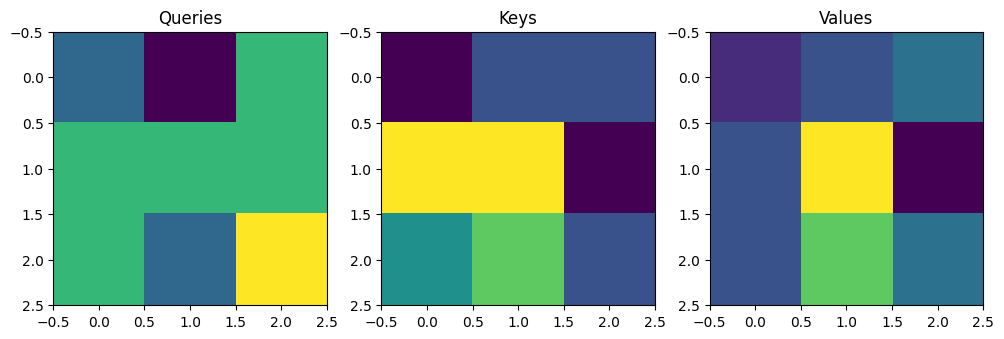

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(queries)
ax[0].set_title("Queries")

ax[1].imshow(keys)
ax[1].set_title("Keys")

ax[2].imshow(values)
ax[2].set_title("Values")

plt.show()

**Calculate Attention Scores**

In [ ]:
# ----------------------------------------------------------
# Compare every Query with every Key.
#
# Dot Product
#
# Query × Key^T
# ----------------------------------------------------------

attention_scores = queries @ keys.T

print("Attention Scores")

print(attention_scores)

print("\nShape :", attention_scores.shape)

Attention Scores
tensor([[ 2.,  4.,  4.],
        [ 4., 16., 12.],
        [ 4., 12., 10.]])

Shape : torch.Size([3, 3])


**Visualize Attention Scores**

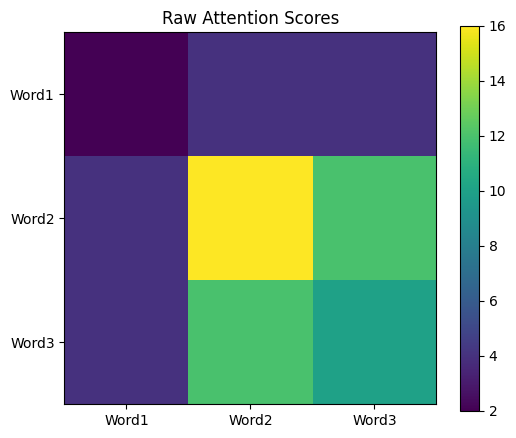

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(attention_scores)

plt.colorbar()

plt.xticks([0,1,2],["Word1","Word2","Word3"])
plt.yticks([0,1,2],["Word1","Word2","Word3"])

plt.title("Raw Attention Scores")

plt.show()

**Normalize Attention Scores Softmax**

In [ ]:
from torch.nn.functional import softmax

attention_weights = softmax(attention_scores,dim=-1)

print(attention_weights)

tensor([[6.3379e-02, 4.6831e-01, 4.6831e-01],
        [6.0337e-06, 9.8201e-01, 1.7986e-02],
        [2.9539e-04, 8.8054e-01, 1.1917e-01]])


**Visualize Attention Weights**

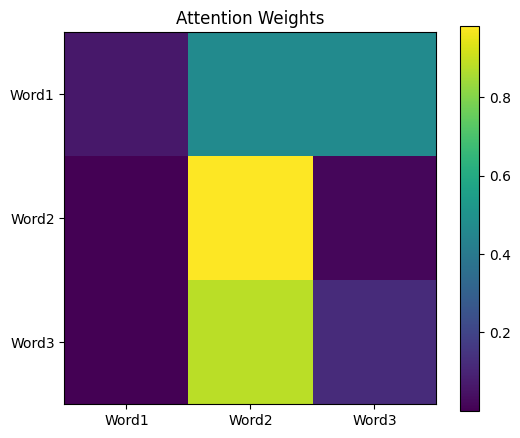

In [ ]:
plt.figure(figsize=(6,5))

plt.imshow(attention_weights)

plt.colorbar()

plt.xticks([0,1,2],["Word1","Word2","Word3"])
plt.yticks([0,1,2],["Word1","Word2","Word3"])

plt.title("Attention Weights")

plt.show()

**Calculate Weighted Values**

In [ ]:
weighted_values = values[:,None] * attention_weights.T[:,:,None]

print(weighted_values)

print(weighted_values.shape)

tensor([[[6.3379e-02, 1.2676e-01, 1.9014e-01],
         [6.0337e-06, 1.2067e-05, 1.8101e-05],
         [2.9539e-04, 5.9077e-04, 8.8616e-04]],

        [[9.3662e-01, 3.7465e+00, 0.0000e+00],
         [1.9640e+00, 7.8561e+00, 0.0000e+00],
         [1.7611e+00, 7.0443e+00, 0.0000e+00]],

        [[9.3662e-01, 2.8099e+00, 1.4049e+00],
         [3.5972e-02, 1.0792e-01, 5.3958e-02],
         [2.3834e-01, 7.1501e-01, 3.5750e-01]]])
torch.Size([3, 3, 3])


**Sum Weighted Values Final Self Attention Output**

In [ ]:
outputs = weighted_values.sum(dim=0)

print("Self Attention Output")

print(outputs)

Self Attention Output
tensor([[1.9366, 6.6831, 1.5951],
        [2.0000, 7.9640, 0.0540],
        [1.9997, 7.7599, 0.3584]])


**Easy Method (Matrix Multiplication)**

In [ ]:
outputs2 = attention_weights @ values

print(outputs2)

tensor([[1.9366, 6.6831, 1.5951],
        [2.0000, 7.9640, 0.0540],
        [1.9997, 7.7599, 0.3584]])


**Verify Both Methods**

In [ ]:
print(torch.allclose(outputs, outputs2))

True


**Complete Self Attention Pipeline**

In [ ]:
from torch.nn.functional import softmax

# Step 1
keys = x @ w_key

# Step 2
queries = x @ w_query

# Step 3
values = x @ w_value

# Step 4
scores = queries @ keys.T

# Step 5
weights = softmax(scores,dim=-1)

# Step 6
outputs = weights @ values

print(outputs)

tensor([[1.9366, 6.6831, 1.5951],
        [2.0000, 7.9640, 0.0540],
        [1.9997, 7.7599, 0.3584]])


# Simulation

In [ ]:
# ==========================================================
# SELF ATTENTION SIMULATOR
# Educational Interactive Demo
# ==========================================================

import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# ----------------------------------------------------------
# Self Attention Function
# ----------------------------------------------------------

def self_attention(sentence):

    tokens = sentence.strip().split()

    if len(tokens) < 2:
        return (
            "Please enter at least two words.",
            None,
            None,
            None,
            None,
            None,
            None,
            None,
        )

    embedding_dim = 4

    embeddings = {}

    for token in tokens:
        embeddings[token] = np.round(
            np.random.rand(embedding_dim),2
        )

    X = np.array([embeddings[t] for t in tokens])

    # ------------------------------------------------------
    # Weight Matrices
    # ------------------------------------------------------

    WQ = np.round(np.random.rand(embedding_dim, embedding_dim),2)
    WK = np.round(np.random.rand(embedding_dim, embedding_dim),2)
    WV = np.round(np.random.rand(embedding_dim, embedding_dim),2)

    # ------------------------------------------------------
    # Query Key Value
    # ------------------------------------------------------

    Q = X @ WQ
    K = X @ WK
    V = X @ WV

    # ------------------------------------------------------
    # Attention Scores
    # ------------------------------------------------------

    scores = Q @ K.T

    # ------------------------------------------------------
    # Scaling
    # ------------------------------------------------------

    dk = embedding_dim
    scaled_scores = scores / np.sqrt(dk)

    # ------------------------------------------------------
    # Softmax
    # ------------------------------------------------------

    exp = np.exp(scaled_scores - np.max(scaled_scores,axis=1,keepdims=True))
    attention = exp / exp.sum(axis=1,keepdims=True)

    # ------------------------------------------------------
    # Context Vector
    # ------------------------------------------------------

    context = attention @ V

    # ------------------------------------------------------
    # DataFrames
    # ------------------------------------------------------

    emb_df = pd.DataFrame(
        X,
        index=tokens,
        columns=[f"E{i+1}" for i in range(embedding_dim)]
    )

    q_df = pd.DataFrame(
        np.round(Q,2),
        index=tokens,
        columns=[f"Q{i+1}" for i in range(embedding_dim)]
    )

    k_df = pd.DataFrame(
        np.round(K,2),
        index=tokens,
        columns=[f"K{i+1}" for i in range(embedding_dim)]
    )

    v_df = pd.DataFrame(
        np.round(V,2),
        index=tokens,
        columns=[f"V{i+1}" for i in range(embedding_dim)]
    )

    score_df = pd.DataFrame(
        np.round(scores,2),
        index=tokens,
        columns=tokens
    )

    attention_df = pd.DataFrame(
        np.round(attention,3),
        index=tokens,
        columns=tokens
    )

    context_df = pd.DataFrame(
        np.round(context,2),
        index=tokens,
        columns=[f"C{i+1}" for i in range(embedding_dim)]
    )

    # ------------------------------------------------------
    # Heatmap
    # ------------------------------------------------------

    fig, ax = plt.subplots(figsize=(7,5))

    sns.heatmap(
        attention_df,
        annot=True,
        cmap="Blues",
        fmt=".2f",
        xticklabels=tokens,
        yticklabels=tokens,
        ax=ax
    )

    ax.set_title("Attention Weight Matrix")

    explanation = f"""

SELF ATTENTION STEP BY STEP

Sentence:

{sentence}

----------------------------------------------------

Step 1

Each word is converted into an embedding vector.

↓

Step 2

Each embedding is multiplied with

• WQ → Query

• WK → Key

• WV → Value

↓

Step 3

Each Query compares itself with every Key.

Formula:

Score = Q × Kᵀ

This tells us

"Which words should I pay attention to?"

↓

Step 4

Scores are divided by √d

to prevent extremely large values.

↓

Step 5

Softmax converts scores into probabilities.

Every row sums to 1.

↓

Step 6

Each Value vector is multiplied by its attention weight.

↓

Step 7

Weighted Values are summed.

This produces the Context Vector.

The Context Vector is the new representation of every word after considering all other words.

"""

    return (
        explanation,
        emb_df,
        q_df,
        k_df,
        v_df,
        score_df,
        attention_df,
        fig,
    )


# ----------------------------------------------------------
# Gradio UI
# ----------------------------------------------------------

with gr.Blocks(title="Self Attention Simulator") as demo:

    gr.Markdown(
        """
# 🧠 Self Attention Interactive Simulator

Enter any sentence and observe how Self Attention works step-by-step.
"""
    )

    sentence = gr.Textbox(
        value="The cat sat on the mat",
        label="Input Sentence"
    )

    btn = gr.Button("Run Self Attention")

    explanation = gr.Textbox(
        label="Explanation",
        lines=22
    )

    embedding_table = gr.Dataframe(label="Word Embeddings")

    query_table = gr.Dataframe(label="Query Matrix (Q)")

    key_table = gr.Dataframe(label="Key Matrix (K)")

    value_table = gr.Dataframe(label="Value Matrix (V)")

    score_table = gr.Dataframe(label="Attention Scores (QKᵀ)")

    attention_table = gr.Dataframe(label="Attention Weights After Softmax")

    heatmap = gr.Plot(label="Attention Heatmap")

    btn.click(
        self_attention,
        inputs=sentence,
        outputs=[
            explanation,
            embedding_table,
            query_table,
            key_table,
            value_table,
            score_table,
            attention_table,
            heatmap,
        ],
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d9e276858e4c56cb2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
